![Health-Informatics: A Python Tutorial](../../Image/chapter-banner.png)


# Module 12:  Public Health and Population Informatics



**Health Informatics in Python** · Part IV: Advanced Topics · Module 12 of 16

---



Clinical informatics focuses on the individual patient; **public health
informatics** shifts the unit of analysis to the **population**. This module covers
disease surveillance, reportable conditions, syndromic monitoring, registries, and
the standards that move data from clinics to health departments.


## Learning objectives

By the end of this module you will be able to:

1. Explain **disease surveillance** and the difference between **case-based** and
   **syndromic** surveillance.
2. Implement a **reportable-condition** trigger from clinical data.
3. Build a **syndromic time series** and detect an **aberration** (outbreak signal).
4. Construct a simple **disease registry** and compute population indicators.
5. Name the public-health reporting standards: **eCR** and **ELR**.


## Dataset

The synthetic EHR aggregated to the **population** level, plus a **daily syndromic
time series** we derive from encounters and into which we inject a synthetic
outbreak so the aberration detector has something to find.


In [19]:
# --- Self-contained synthetic EHR generator (identical to earlier parts) ---
import numpy as np
import pandas as pd

# This function creates a synthetic Electronic Health Record (EHR) dataset with multiple tables.
def make_synthetic_ehr(n_patients=200, seed=42):
    rng = np.random.default_rng(seed)

    # 1. Generate basic patient demographics
    first = ["Ava","Liam","Noah","Mia","Zoe","Omar","Ivan","Sara","Leo","Nina",
             "Ruth","Kai","Yara","Theo","Ida","Sam","Ana","Eli","Rex","Uma"]
    last  = ["Khan","Ortiz","Chen","Diaz","Patel","Ali","Brown","Nash","Reed","Vega",
             "Cole","Frost","Grant","Hale","Iqbal","Jain","Kerr","Lund","Mora","Park"]
    ages  = rng.integers(18, 90, size=n_patients)
    patients = pd.DataFrame({
        "patient_id": [f"P{1000+i}" for i in range(n_patients)],
        "given_name": rng.choice(first, size=n_patients),
        "family_name": rng.choice(last, size=n_patients),
        "sex": rng.choice(["male","female"], size=n_patients, p=[0.49,0.51]),
        "age": ages,
        "birth_year": 2026 - ages,
    })

    # 2. Simulate encounters for each patient (each patient has 1-4 encounters)
    enc_rows, enc_types = [], ["ambulatory","emergency","inpatient","wellness"]
    for pid in patients["patient_id"]:
        for _ in range(rng.integers(1, 5)):
            day = rng.integers(0, 365*3)  # encounter at random day over 3 years
            enc_rows.append({
                "encounter_id": f"E{len(enc_rows)+1:05d}",
                "patient_id": pid,
                "encounter_type": rng.choice(enc_types, p=[0.55,0.15,0.10,0.20]),
                "date": (pd.Timestamp("2023-01-01") + pd.Timedelta(days=int(day))).date()
            })
    encounters = pd.DataFrame(enc_rows)

    # 3. Generate observations for each encounter (70% chance per observation type per encounter)
    obs_defs = [
        ("Body height","cm",150,195),
        ("Body weight","kg",50,110),
        ("Systolic blood pressure","mmHg",100,165),
        ("Heart rate","/min",55,100),
        ("Hemoglobin A1c","%",4.8,9.5)
    ]
    obs_rows = []
    for _, e in encounters.iterrows():
        for name, unit, lo, hi in obs_defs:
            if rng.random() < 0.7:  # 70% probability to record the observation
                obs_rows.append({
                    "observation_id": f"O{len(obs_rows)+1:06d}",
                    "encounter_id": e["encounter_id"],
                    "patient_id": e["patient_id"],
                    "observation": name,
                    "value": round(float(rng.uniform(lo,hi)), 1),
                    "unit": unit,
                    "date": e["date"]
                })
    observations = pd.DataFrame(obs_rows)

    # 4. Assign 0-3 random conditions per patient from a predefined pool
    cond_pool = [
        "Essential hypertension","Type 2 diabetes mellitus","Asthma",
        "Acute bronchitis","Major depressive disorder","Osteoarthritis",
        "Chronic kidney disease","Anemia"
    ]
    cond_rows = []
    for pid in patients["patient_id"]:
        for c in rng.choice(cond_pool, size=rng.integers(0,4), replace=False):
            cond_rows.append({
                "condition_id": f"C{len(cond_rows)+1:05d}",
                "patient_id": pid,
                "condition": c
            })
    conditions = pd.DataFrame(cond_rows)

    # 5. Assign 0-3 random medications per patient from a medication pool
    med_pool = [
        "Lisinopril","Metformin","Albuterol","Atorvastatin","Sertraline",
        "Amoxicillin","Ibuprofen","Hydrochlorothiazide"
    ]
    med_rows = []
    for pid in patients["patient_id"]:
        for m in rng.choice(med_pool, size=rng.integers(0,4), replace=False):
            med_rows.append({
                "medication_id": f"M{len(med_rows)+1:05d}",
                "patient_id": pid,
                "medication": m
            })
    medications = pd.DataFrame(med_rows)

    # Return the complete synthetic EHR as a dictionary of tables
    return {
        "patients": patients,
        "encounters": encounters,
        "observations": observations,
        "conditions": conditions,
        "medications": medications
    }

# Actually generate the data and display a summary of each table's size
ehr = make_synthetic_ehr()
print("Tables:", ", ".join(f"{k} ({len(v)})" for k,v in ehr.items()))


Tables: patients (200), encounters (511), observations (1804), conditions (304), medications (276)


## 12.1 Two modes of surveillance

**Case-based (notifiable disease) surveillance** involves the mandatory reporting of specific, confirmed diagnoses, such as measles or tuberculosis, to public health authorities. Each case is investigated and reported individually, which ensures very high specificity and data accuracy. However, because reporting relies on confirmation (often lab-based) and follow-up, this approach is slower and less useful for providing early warning of emerging health threats.

**Syndromic surveillance** monitors patterns of health-related data before a definitive diagnosis is made. It tracks symptoms, chief complaints, or visit counts in sources like emergency departments to rapidly detect unusual trends (such as an uptick in respiratory symptoms). This method is much faster, enabling early detection and potentially timely interventions, but it is less specific: many different diseases or non-infectious conditions can cause similar symptom patterns, making the data "noisy" and prone to false alarms.

In practice, public health systems use both approaches: syndromic surveillance provides rapid alerts for unexpected activity, allowing early situational awareness, while case-based reporting follows as a more definitive, confirmatory process that guides official response and containment.


## 12.2 Reportable-condition triggers

Certain diagnoses, such as specific infectious diseases or conditions with significant public health impact, are **legally reportable** to government authorities. This means that, when a healthcare provider or EHR system records the diagnosis of such a condition, an automated process (called a "trigger") identifies the case and prepares the relevant clinical information for prompt, secure transmission. This process is known as **electronic case reporting (eCR)**. eCR enables rapid, standardized, and reliable notification to public health agencies—ensuring they are alerted about new cases quickly enough to investigate, monitor trends, and initiate appropriate disease control or preventive actions.


In [20]:
import pandas as pd

# Define two lists mimicking reportable conditions and those that are actually notifiable (require action).
# In reality, these lists are determined by state or national public health laws and may be much longer.
REPORTABLE = {
    "Acute bronchitis": "respiratory-syndrome-monitored",    # Imagine this code means the condition is tracked for public health
    "Asthma": "chronic-not-reportable"                      # While asthma is relevant, it's not mandated for reporting here
}
NOTIFIABLE = {"Acute bronchitis"}  # Of the reportable list, this condition is to be automatically flagged for action

# Extract the 'conditions' table from our synthetic electronic health record (EHR)
cond = ehr["conditions"]

# Find all rows where the patient's condition matches a 'notifiable' condition, i.e., should be reported
triggered = cond[cond["condition"].isin(NOTIFIABLE)].copy()

# Annotate these flagged rows with a new column: the type of report they trigger (here, an "electronic case report" or eCR)
triggered["report_type"] = "eCR (electronic case report)"

# Print how many cases were triggered for reporting
print(f"Reportable cases triggered: {len(triggered)}")

# Display a few columns (patient id, condition, report type) of the first triggered cases, without row index numbers
print(triggered[["patient_id", "condition", "report_type"]].head().to_string(index=False))

Reportable cases triggered: 45
patient_id        condition                  report_type
     P1001 Acute bronchitis eCR (electronic case report)
     P1006 Acute bronchitis eCR (electronic case report)
     P1023 Acute bronchitis eCR (electronic case report)
     P1029 Acute bronchitis eCR (electronic case report)
     P1030 Acute bronchitis eCR (electronic case report)


## 12.3 Building a syndromic time series

Syndromic surveillance is concerned with monitoring trends by tracking **how counts of specific health events change over time**. 
In this example, we construct a time series by tallying the number of respiratory-related emergency encounters for each day. 
To demonstrate how syndromic surveillance detects unusual activity, we artificially add (or "inject") a surge of cases—a **synthetic outbreak**—in the middle of the series. 
This creates an abnormal spike in counts, mimicking the kind of sudden event that surveillance systems are designed to identify as a potential public health concern.


In [21]:
import numpy as np

# Make a copy of the encounters table and ensure the 'date' column is in datetime format
enc = ehr["encounters"].copy()
enc["date"] = pd.to_datetime(enc["date"])

# Calculate the number of emergency encounters per day:
# 1. Filter to only emergency encounters
# 2. Group by date, count occurrences, and name the result 'count'
daily = (
    enc[enc["encounter_type"] == "emergency"]
    .groupby("date")
    .size()
    .rename("count")
)

# Create a complete date range from the earliest to latest encounter date, one entry per day
idx = pd.date_range(enc["date"].min(), enc["date"].max(), freq="D")
# Reindex the series to this full date range, filling days with no events with zero
daily = daily.reindex(idx, fill_value=0)

# Simulate a 10-day outbreak in the middle of the time series by adding elevated counts for those days
rng = np.random.default_rng(7)  # Fixed seed for reproducibility
outbreak_start = daily.index[len(daily) // 2]  # Middle date of the series
outbreak_days = pd.date_range(outbreak_start, periods=10, freq="D")
daily.loc[outbreak_days] += rng.integers(4, 9, size=10)  # Add 4-8 events per outbreak day

# Output summary stats
print("Daily syndromic series built:", len(daily), "days")
# Baseline mean is calculated as the average count in the first quarter of the series
print("Baseline mean:", round(daily.iloc[:len(daily) // 4].mean(), 2))

Daily syndromic series built: 1094 days
Baseline mean: 0.05


### Milestone 1 - aberration detection (a simple EARS-style C1)

Aberration detection involves identifying days where the number of observed events is unexpectedly high compared to recent history.

In this example, we use a simple version of the CDC EARS (Early Aberration Reporting System) method, specifically the C1 algorithm:
- For each day, we calculate the mean and standard deviation of event counts over a trailing baseline window (e.g., the previous 14 days, not including the current day).
- We set a threshold as: mean + k × standard deviation (where k is typically 3).
- Any day where the observed count exceeds this threshold is flagged as a possible aberration ("alarm").

This technique allows us to automatically detect sudden, unusual increases in health events, such as might occur in a disease outbreak.

In [22]:
# Function to detect statistical aberrations in a time series using a simplified CDC EARS C1 algorithm.
# This identifies days where the number of observed events ("count") is unexpectedly high 
# compared to the preceding days, indicating a possible outbreak.

def detect_aberrations(series, window=14, k=3):
    # Calculate the rolling mean and std dev for a trailing window (excluding the current day)
    # shift(1) ensures the current day's value is not included in the window.
    roll_mean = series.rolling(window, min_periods=7).mean().shift(1)
    roll_std  = series.rolling(window, min_periods=7).std().shift(1).fillna(1)  # Use 1 as default std if insufficient prior data
    
    # The threshold for flagging a potential aberration: mean + k*std
    threshold = roll_mean + k * roll_std
    
    # Alarm (True/False): did today's count exceed the calculated threshold?
    flags = series > threshold
    
    # Return a DataFrame showing the day's count, calculated threshold, and alarm status
    return pd.DataFrame({
        "count": series,
        "threshold": threshold.round(1),
        "alarm": flags
    })

# Apply aberration detection to the daily time series
signal = detect_aberrations(daily)

# Extract the days that triggered alarms (potential outbreaks)
alarms = signal[signal["alarm"]]

print(f"Aberration days flagged: {len(alarms)}")
# Display first 8 alarms with their observed count and calculated threshold
print(alarms.head(8)[["count", "threshold"]].to_string())

Aberration days flagged: 49
            count  threshold
2023-03-04      1        0.0
2023-04-08      1        0.0
2023-06-01      1        0.0
2023-06-10      1        0.9
2023-06-27      1        0.0
2023-06-28      1        0.9
2023-07-27      1        0.0
2023-07-30      1        0.9


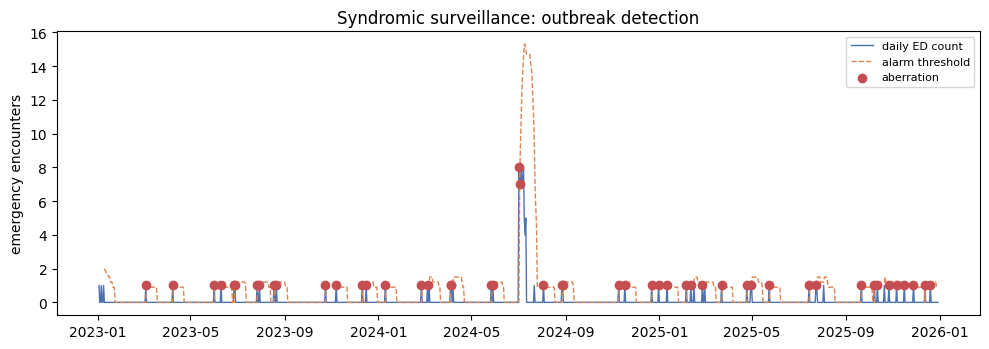

In [23]:
# Plot the time series with detected aberrations and thresholds for visual inspection.

import matplotlib.pyplot as plt

# Create a figure and axis for plotting, specifying the size.
fig, ax = plt.subplots(figsize=(10, 3.6))

# Plot the daily emergency department (ED) counts in blue.
ax.plot(
    signal.index, 
    signal["count"], 
    color="#4C72B0", 
    lw=1, 
    label="daily ED count"
)

# Plot the alarm threshold (mean + 3*std), showing when an aberration would trigger, in orange dashed line.
ax.plot(
    signal.index, 
    signal["threshold"], 
    color="#DD8452", 
    ls="--", 
    lw=1, 
    label="alarm threshold"
)

# Mark aberration days (when alarm is True) as red dots.
ax.scatter(
    alarms.index, 
    alarms["count"], 
    color="#C44E52", 
    zorder=5, 
    label="aberration"
)

# Add a title and Y-axis label.
ax.set_title("Syndromic surveillance: outbreak detection")
ax.set_ylabel("emergency encounters")

# Show a legend with smaller font.
ax.legend(fontsize=8)

# Adjust layout and show the plot.
plt.tight_layout()
plt.show()

## 12.4 Disease registries

A **registry** is an organized database that contains a systematically assembled group of individuals who share a specific condition or set of characteristics. These registries are actively maintained and track individuals over time for purposes such as public health surveillance, monitoring care quality, research, and improving clinical outcomes. 

Examples include cancer registries, which record cancer diagnoses and follow up with patients over years, or diabetes registries, where people diagnosed with diabetes are monitored for changes in health status, treatment outcomes, and population-level trends.

Disease registries collect key data points including diagnoses, laboratory results, demographics, treatments, and outcomes, making it possible to calculate statistics (indicators) such as incidence and prevalence rates, mortality, and measures of disease control.

In the code below, we create a diabetes registry by identifying patients with Type 2 diabetes mellitus (T2DM) either by having a coded diagnosis or an elevated Hemoglobin A1c (A1c ≥ 6.5), and then compute population health indicators based on this curated group.


In [24]:
# --- Create a diabetes registry: patients with either a T2DM diagnosis OR elevated A1c (≥ 6.5) ---

# 1. Gather all lab observations.
obs = ehr["observations"]

# 2. Identify patients with a diagnosis code for Type 2 diabetes mellitus (T2DM).
dx_dm = set(cond[cond["condition"] == "Type 2 diabetes mellitus"]["patient_id"])

# 3. For each patient, get their highest Hemoglobin A1c lab value.
a1c = (
    obs[obs["observation"] == "Hemoglobin A1c"]
    .groupby("patient_id")["value"]
    .max()
)

# 4. Identify patients who have ever had an A1c indicating diabetes (A1c ≥ 6.5).
lab_dm = set(a1c[a1c >= 6.5].index)

# 5. Combine patients identified by diagnosis or by lab result to form the registry.
registry_ids = dx_dm | lab_dm

# 6. Extract patient records for those in the registry.
registry = ehr["patients"][ehr["patients"]["patient_id"].isin(registry_ids)].copy()

# 7. Merge each registry patient with their highest recorded A1c value (if any).
registry = registry.merge(a1c.rename("max_a1c"), on="patient_id", how="left")

# 8. Compute population metrics and output summary:
n_total = len(ehr["patients"])
print(f"Diabetes registry: {len(registry)} patients ({len(registry)/n_total:.1%} of population)")
print(f"  identified by diagnosis: {len(dx_dm)} | by A1c lab: {len(lab_dm)}")
print(f"  mean age: {registry['age'].mean():.1f}")
print(f"  % with poor control (A1c>=8): "
      f"{(registry['max_a1c']>=8).mean():.1%}")
 

Diabetes registry: 160 patients (80.0% of population)
  identified by diagnosis: 40 | by A1c lab: 146
  mean age: 53.2
  % with poor control (A1c>=8): 60.6%


## 12.5 Public-health reporting standards

In public health, two main automated standards ensure that important clinical and laboratory data from clinics and hospitals are sent quickly and reliably to health departments:

- **eCR (electronic Case Reporting)** — This system automatically sends reports about specific health conditions (called "reportable conditions," like tuberculosis or HIV) from the electronic health record (EHR) system to public health departments. The trigger can be a diagnosis, lab result, or other EHR event. Information is sent using standardized clinical document formats such as FHIR (Fast Healthcare Interoperability Resources) or CDA (Clinical Document Architecture). eCR allows public health agencies to receive timely details about new cases, demographics, provider information, and other relevant clinical data automatically, without manual paperwork.

- **ELR (electronic Laboratory Reporting)** — This standard is used specifically for laboratory test results. When a laboratory identifies a positive result for a reportable infectious disease (for example, a positive blood culture for Salmonella), the information is sent directly to the relevant public health authorities, usually using the HL7 Version 2 messaging standard. ELR provides structured data about laboratory findings, specimen types, collection dates, and results, speeding up case detection and outbreak investigations.

Both eCR and ELR have replaced older, manual methods like phone calls or faxing of results, dramatically reducing reporting delays and enabling near-real-time disease surveillance and rapid public health response to new cases.



## Exercises

1. Add a **7-day moving average** overlay to the syndromic chart and compare its
   smoothness to the raw counts.
2. Build an **age-stratified** diabetes registry table (counts by age band) - a
   standard public-health denominator breakdown.
3. Implement a second detector (e.g. a simple **CUSUM**) and compare which days it
   flags versus the control-chart method.



## Key takeaways

- Public health informatics operates on **populations**, using **case-based** and
  **syndromic** surveillance together.
- **Aberration detection** on time series gives early outbreak warning.
- **Registries** turn scattered records into trackable disease cohorts.
- **eCR** and **ELR** are the standards that automate clinic→public-health reporting.



---
*Next: Module 13 - Claims Data Analysis.*
